In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score,precision_score, recall_score,f1_score,mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression,LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVC,LinearSVC
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict,GridSearchCV,train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor


import kagglehub
import os



In [2]:
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

file_path = os.path.join(path, "Student_Performance.csv")

df = pd.read_csv(file_path)

Path to dataset files: C:\Users\mar_c\.cache\kagglehub\datasets\nikhil7280\student-performance-multiple-linear-regression\versions\1


# EDA

In [3]:
print(df.shape)

print(df.head())

(10000, 6)
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [4]:
# Ver tipos de datos
print(df.dtypes)

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [5]:
# Ver valores nulos por columna
print(df.isnull().sum())

# Ver duplicados
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())

# Resumen estadístico
print("\nResumen estadístico:")
print(df.describe().T)

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

Cantidad de filas duplicadas:
127

Resumen estadístico:
                                    count     mean        std   min   25%  \
Hours Studied                     10000.0   4.9929   2.589309   1.0   3.0   
Previous Scores                   10000.0  69.4457  17.343152  40.0  54.0   
Sleep Hours                       10000.0   6.5306   1.695863   4.0   5.0   
Sample Question Papers Practiced  10000.0   4.5833   2.867348   0.0   2.0   
Performance Index                 10000.0  55.2248  19.212558  10.0  40.0   

                                   50%   75%    max  
Hours Studied                      5.0   7.0    9.0  
Previous Scores                   69.0  85.0   99.0  
Sleep Hours                        7.0   8.0    9.0  
Sample Question Papers 

In [6]:
# Definir variable objetivo
target = "Performance Index"

# Separar variables
X = df.drop(columns=[target])
y = df[target]

# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Target:", target)
print("Numéricas:", columnas_numericas)
print("Categóricas:", columnas_categoricas)

Target: Performance Index
Numéricas: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
Categóricas: ['Extracurricular Activities']


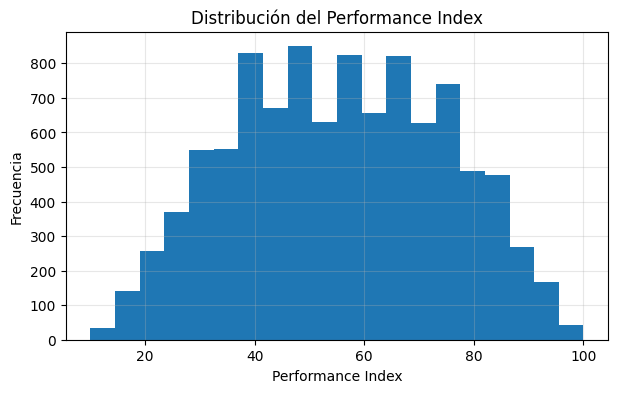

count    10000.000000
mean        55.224800
std         19.212558
min         10.000000
25%         40.000000
50%         55.000000
75%         71.000000
max        100.000000
Name: Performance Index, dtype: float64


In [7]:
plt.figure(figsize=(7,4))
plt.hist(y, bins=20)
plt.title("Distribución del Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Frecuencia")
plt.grid(True, alpha=0.3)
plt.show()

# Estadística básica del target
print(y.describe())

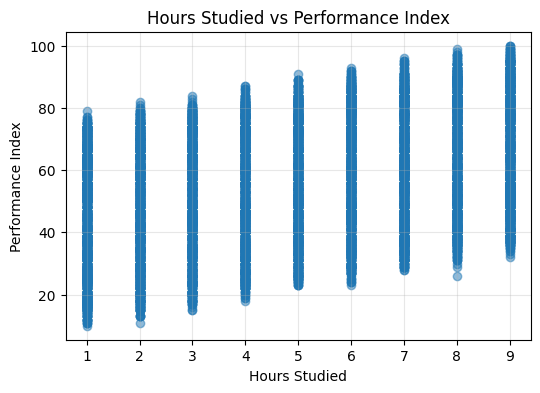

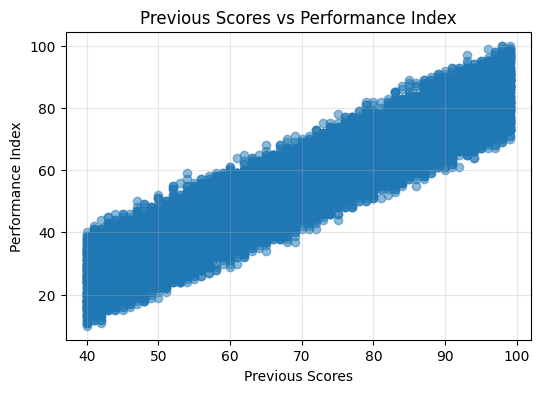

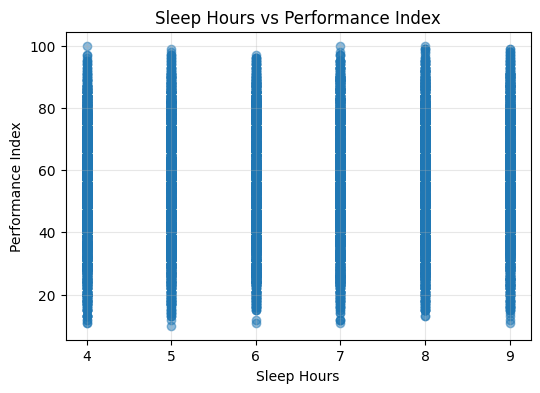

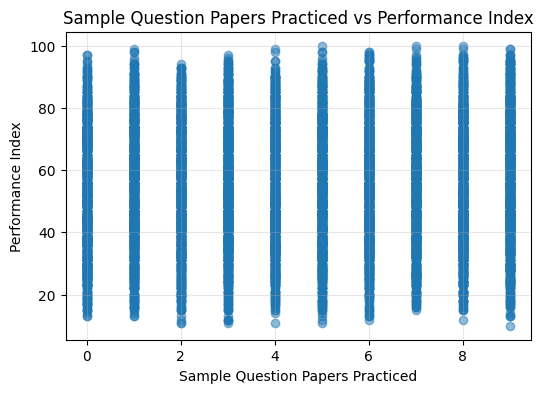

In [8]:
##Como cambia el performance index con respecto a las variables numéricas
for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], y, alpha=0.5)
    plt.title(f"{col} vs Performance Index")
    plt.xlabel(col)
    plt.ylabel("Performance Index")
    plt.grid(True, alpha=0.3)
    plt.show()

In [9]:
correlaciones = df[columnas_numericas + [target]].corr()[target].sort_values(ascending=False)

print("Correlación con Performance Index:")
print(correlaciones)

Correlación con Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


Extracurricular Activities
No     54.758511
Yes    55.700889
Name: Performance Index, dtype: float64


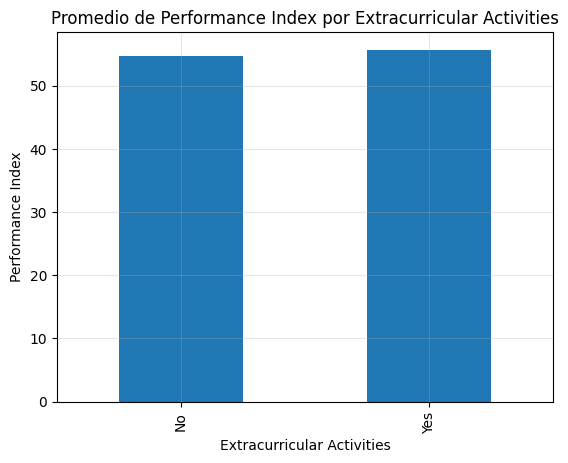

In [10]:
# Promedio del target por variables categóricas
resumen_cat = df.groupby("Extracurricular Activities")[target].mean()
print(resumen_cat)

# Gráfico
resumen_cat.plot(kind="bar")
plt.title("Promedio de Performance Index por Extracurricular Activities")
plt.ylabel("Performance Index")
plt.grid(True, alpha=0.3)
plt.show()

## No impacta mucho ya que no exista tanta diferencia entre los grupos con respecto a su calificacion

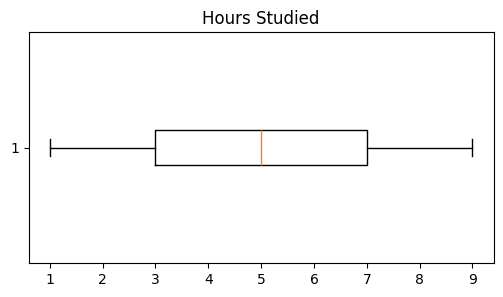

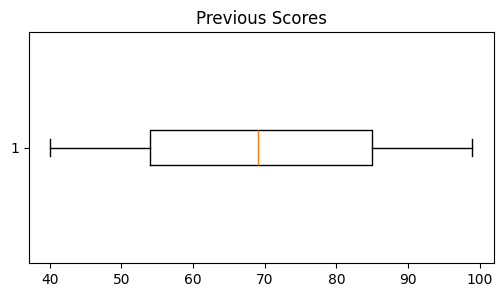

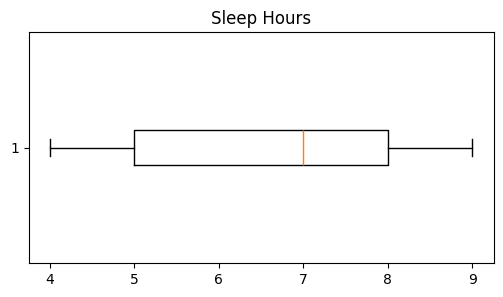

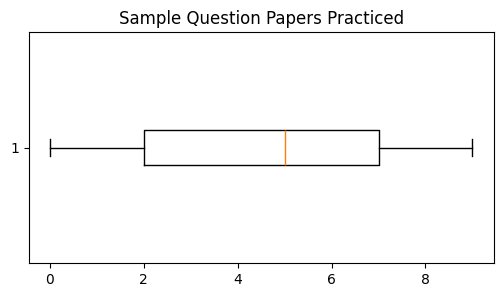

In [11]:
##Busqueda de outliers con boxplot
for col in columnas_numericas:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

# Split and normalization

In [12]:
# SPLIT + PREPROCESAMIENTO (CON Y SIN NORMALIZACIÓN)

# Definir target y features
target = "Performance Index"

X = df.drop(columns=[target])
y = df[target]

# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Preprocesamiento con normalización (para regresión, SVM, KNN)
preprocesamiento_con_scaling = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(drop="first"), columnas_categoricas)
    ]
)

# Ajustar solo con train
X_train_scaled = preprocesamiento_con_scaling.fit_transform(X_train)
X_test_scaled = preprocesamiento_con_scaling.transform(X_test)

print("\nDatos con scaling:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# Preprocesamiento sin normalización (para árboles)
preprocesamiento_sin_scaling = ColumnTransformer(
    transformers=[
        ("num", "passthrough", columnas_numericas),
        ("cat", OneHotEncoder(drop="first"), columnas_categoricas)
    ]
)

# Ajustar solo con train
X_train_no_scaled = preprocesamiento_sin_scaling.fit_transform(X_train)
X_test_no_scaled = preprocesamiento_sin_scaling.transform(X_test)

print("\nDatos sin scaling:")
print("X_train_no_scaled shape:", X_train_no_scaled.shape)
print("X_test_no_scaled shape:", X_test_no_scaled.shape)


Shapes:
X_train: (8000, 5)
X_test: (2000, 5)
y_train: (8000,)
y_test: (2000,)

Datos con scaling:
X_train_scaled shape: (8000, 5)
X_test_scaled shape: (2000, 5)

Datos sin scaling:
X_train_no_scaled shape: (8000, 5)
X_test_no_scaled shape: (2000, 5)


# Modelos

## Modelo de regresion Lineal

In [13]:
# 1. Crear pipeline final (preprocesamiento + modelo)
modelo_lr = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_con_scaling),
    ("modelo", LinearRegression())
])

# 2. Entrenar modelo
modelo_lr.fit(X_train, y_train)

# 3. Predicciones
y_pred_train = modelo_lr.predict(X_train)
y_pred_test = modelo_lr.predict(X_test)

# 4. Evaluación
print("----- TRAIN -----")
print("MAE:", mean_absolute_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2:", r2_score(y_train, y_pred_train))

print("\n----- TEST -----")
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R2:", r2_score(y_test, y_pred_test))

##MAE : Error promedio en unidades del target, osea 1.619
## RMSE : Error promedio en unidades del target, pero penalizando más los errores grandes, osea 2.08
## R2 : Proporción de varianza explicada por el modelo, ENTRE 0 y 1, donde 1 es perfecto y 0 significa que el modelo no explica nada de la variabilidad del target. En este caso, un R2 de 0.85 indica que el modelo explica el 98% de la variabilidad del Performance Index.

----- TRAIN -----
MAE: 1.6193054830334264
RMSE: 2.0419931071198567
R2: 0.9886898790682355

----- TEST -----
MAE: 1.6111213463123026
RMSE: 2.0205515085050028
R2: 0.9889832909573145


## Ridge

Probar valores diferentes de alpha

In [14]:


# # 1. Lista de valores de alpha
# alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# # 2. Lista para guardar resultados
# resultados = []

# # 3. Loop sobre cada alpha
# for alpha in alphas:
    
#     modelo = Pipeline(steps=[
#         ("preprocesamiento", preprocesamiento_con_scaling),
#         ("modelo", Ridge(alpha=alpha))
#     ])
    
#     # Entrenar
#     modelo.fit(X_train, y_train)
    
#     # Predicciones
#     y_pred_test = modelo.predict(X_test)
    
#     # Métricas
#     mae = mean_absolute_error(y_test, y_pred_test)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
#     r2 = r2_score(y_test, y_pred_test)
    
#     resultados.append({
#         "alpha": alpha,
#         "MAE": mae,
#         "RMSE": rmse,
#         "R2": r2
#     })

# # 4. Convertir a DataFrame
# df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE")

# print(df_resultados)

In [15]:

# 1. Definir modelo final Ridge
modelo_ridge_final = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_con_scaling),
    ("modelo", Ridge(alpha=0.001))
])

# 2. Entrenar con todo el set de entrenamiento
modelo_ridge_final.fit(X_train, y_train)

# 3. Predicciones en train y test
y_pred_train = modelo_ridge_final.predict(X_train)
y_pred_test = modelo_ridge_final.predict(X_test)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)


----- TRAIN -----
MAE: 1.6193054779647729
RMSE: 2.041993107121275
R2: 0.9886898790682198

----- TEST -----
MAE: 1.6111214443659756
RMSE: 2.0205516520478484
R2: 0.9889832893920292


## Lasso Regression

In [16]:


# # 1. Lista de valores de alpha
# alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

# # 2. Lista para guardar resultados
# resultados = []

# # 3. Probar cada alpha
# for alpha in alphas:
    
#     modelo = Pipeline(steps=[
#         ("preprocesamiento", preprocesamiento_con_scaling),
#         ("modelo", Lasso(alpha=alpha, max_iter=10000))
#     ])
    
#     # Entrenar modelo
#     modelo.fit(X_train, y_train)
    
#     # Predicciones en test
#     y_pred_test = modelo.predict(X_test)
    
#     # Obtener coeficientes del modelo
#     coeficientes = modelo.named_steps["modelo"].coef_
#     coef_en_cero = np.sum(coeficientes == 0)
    
#     # Guardar resultados
#     resultados.append({
#         "alpha": alpha,
#         "MAE": mean_absolute_error(y_test, y_pred_test),
#         "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
#         "R2": r2_score(y_test, y_pred_test),
#         "coeficientes_en_0": coef_en_cero
#     })

# # 4. Convertir resultados a DataFrame
# df_resultados_lasso = pd.DataFrame(resultados).sort_values(by="RMSE")

# print(df_resultados_lasso)

In [17]:


# 1. Definir modelo final Lasso
modelo_lasso_final = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_con_scaling),
    ("modelo", Lasso(alpha=0.001, max_iter=10000))
])

# 2. Entrenar con todo el set de entrenamiento
modelo_lasso_final.fit(X_train, y_train)

# 3. Predicciones en train y test
y_pred_train = modelo_lasso_final.predict(X_train)
y_pred_test = modelo_lasso_final.predict(X_test)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)


----- TRAIN -----
MAE: 1.6193089877650715
RMSE: 2.0419950711917374
R2: 0.988689857311158

----- TEST -----
MAE: 1.6111593657080623
RMSE: 2.020660659329001
R2: 0.9889821006730343


## Elastic net (union de ridge y lasso)

Buscar hiperparametros de alpha y l1_ratio

In [18]:

# # 1. Pipeline
# pipeline_elastic = Pipeline(steps=[
#     ("preprocesamiento", preprocesamiento_con_scaling),
#     ("modelo", ElasticNet(max_iter=10000))
# ])

# # 2. Grid de parámetros
# param_grid = {
#     "modelo__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
#     "modelo__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
# }

# # 3. Métricas
# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "RMSE": "neg_root_mean_squared_error",
#     "R2": "r2"
# }

# # 4. GridSearch
# grid_elastic = GridSearchCV(
#     estimator=pipeline_elastic,
#     param_grid=param_grid,
#     scoring=scoring,
#     refit="RMSE",
#     cv=5,
#     n_jobs=-1
# )

# # 5. Entrenar
# grid_elastic.fit(X_train, y_train)

# # 6. Construir tabla final limpia
# df_resultados_elastic = pd.DataFrame({
#     "alpha": grid_elastic.cv_results_["param_modelo__alpha"],
#     "l1_ratio": grid_elastic.cv_results_["param_modelo__l1_ratio"],
#     "MAE": -grid_elastic.cv_results_["mean_test_MAE"],
#     "RMSE": -grid_elastic.cv_results_["mean_test_RMSE"],
#     "R2": grid_elastic.cv_results_["mean_test_R2"]
# })

# # 7. Ordenar por mejor R2
# df_resultados_elastic = df_resultados_elastic.sort_values(by="R2", ascending=False)

# df_resultados_elastic

In [19]:

# 1. Definir modelo final Elastic Net
modelo_elastic_final = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_con_scaling),
    ("modelo", ElasticNet(alpha=0.0001, l1_ratio=0.1, max_iter=10000))
])

# 2. Entrenar con todo el set de entrenamiento
modelo_elastic_final.fit(X_train, y_train)

# 3. Predicciones en train y test
y_pred_train = modelo_elastic_final.predict(X_train)
y_pred_test = modelo_elastic_final.predict(X_test)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.6193019653614467
RMSE: 2.041993855188856
R2: 0.9886898707814765

----- TEST -----
MAE: 1.6111940083786431
RMSE: 2.02065667088743
R2: 0.9889821441679221


## Polynomial Regression

In [20]:
# # 1. Preprocesamiento base
# preprocesamiento_poly = ColumnTransformer(
#     transformers=[
#         ("num", "passthrough", columnas_numericas),
#         ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
#     ]
# )

# # 2. Pipeline
# pipeline_poly = Pipeline(steps=[
#     ("preprocesamiento", preprocesamiento_poly),
#     ("poly", PolynomialFeatures(include_bias=False)),
#     ("scaler", StandardScaler()),
#     ("modelo", LinearRegression())
# ])

# # 3. Grid de parámetros
# param_grid = {
#     "poly__degree": [2, 3, 4]
# }

# # 4. Métricas
# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "RMSE": "neg_root_mean_squared_error",
#     "R2": "r2"
# }

# # 5. GridSearch, se usa para validaciones cruzadas y encontrar el mejor grado de polinomio
# grid_poly = GridSearchCV(
#     estimator=pipeline_poly,
#     param_grid=param_grid,
#     scoring=scoring,
#     refit="RMSE",
#     cv=5,
#     n_jobs=-1
# )

# # 6. Entrenar
# grid_poly.fit(X_train, y_train)

# # 7. Construir tabla final limpia
# df_resultados_poly = pd.DataFrame({
#     "degree": grid_poly.cv_results_["param_poly__degree"],
#     "MAE": -grid_poly.cv_results_["mean_test_MAE"],
#     "RMSE": -grid_poly.cv_results_["mean_test_RMSE"],
#     "R2": grid_poly.cv_results_["mean_test_R2"]
# })

# # 8. Ordenar por mejor R2
# df_resultados_poly = df_resultados_poly.sort_values(by="R2", ascending=False)

# df_resultados_poly

In [21]:
# 1. Preprocesamiento base
preprocesamiento_poly = ColumnTransformer(
    transformers=[
        ("num", "passthrough", columnas_numericas),
        ("cat", OneHotEncoder(drop="first"), columnas_categoricas)
    ]
)

# 2. Definir modelo final Polynomial Regression
modelo_poly_final = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_poly),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("modelo", LinearRegression())
])

# 3. Entrenar con todo el set de entrenamiento
modelo_poly_final.fit(X_train, y_train)

# 4. Predicciones en train y test
y_pred_train = modelo_poly_final.predict(X_train)
y_pred_test = modelo_poly_final.predict(X_test)

# 5. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 6. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.6180811747279018
RMSE: 2.0406592433846753
R2: 0.9887046501591211

----- TEST -----
MAE: 1.6115229438315073
RMSE: 2.0200601738937496
R2: 0.9889886481405485


## SVR

In [22]:


# # 1. Pipeline
# pipeline_svr = Pipeline(steps=[
#     ("preprocesamiento", preprocesamiento_con_scaling),
#     ("modelo", SVR(kernel="rbf"))
# ])

# # 2. Grid de parámetros
# param_grid = {
#     "modelo__C": [0.1, 1, 10, 100],
#     "modelo__epsilon": [0.01, 0.1, 0.5, 1],
#     "modelo__gamma": ["scale", "auto", 0.01, 0.1, 1]
# }

# # 3. Métricas
# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "RMSE": "neg_root_mean_squared_error",
#     "R2": "r2"
# }

# # 4. GridSearch
# grid_svr = GridSearchCV(
#     estimator=pipeline_svr,
#     param_grid=param_grid,
#     scoring=scoring,
#     refit="RMSE",
#     cv=5,
#     n_jobs=-1
# )

# # 5. Entrenar
# grid_svr.fit(X_train, y_train)

# # 6. Construir tabla final limpia
# df_resultados_svr = pd.DataFrame({
#     "C": grid_svr.cv_results_["param_modelo__C"],
#     "epsilon": grid_svr.cv_results_["param_modelo__epsilon"],
#     "gamma": grid_svr.cv_results_["param_modelo__gamma"],
#     "MAE": -grid_svr.cv_results_["mean_test_MAE"],
#     "RMSE": -grid_svr.cv_results_["mean_test_RMSE"],
#     "R2": grid_svr.cv_results_["mean_test_R2"]
# })

# # 7. Ordenar por mejor R2
# df_resultados_svr = df_resultados_svr.sort_values(by="R2", ascending=False)

# df_resultados_svr

In [23]:


# 1. Definir modelo final SVR
modelo_svr_final = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento_con_scaling),
    ("modelo", SVR(kernel="rbf", C=100, epsilon=0.10, gamma=0.01))
])

# 2. Entrenar con todo el set de entrenamiento
modelo_svr_final.fit(X_train, y_train)

# 3. Predicciones en train y test
y_pred_train = modelo_svr_final.predict(X_train)
y_pred_test = modelo_svr_final.predict(X_test)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.6221193101144067
RMSE: 2.049615799616604
R2: 0.9886052808491056

----- TEST -----
MAE: 1.6239845038637577
RMSE: 2.0367934239470804
R2: 0.9888054666182706


# Modelos que no necesitan normalizar los datos

## Decision tree

In [24]:

# # 1. Modelo base
# modelo_dt = DecisionTreeRegressor(random_state=42)

# # 2. Grid de hiperparámetros
# param_grid = {
#     "max_depth": [3, 5, 7, 10, None],
#     "min_samples_split": [2, 5, 10, 20],
#     "min_samples_leaf": [1, 2, 5, 10]
# }

# # 3. GridSearchCV
# grid_dt = GridSearchCV(
#     estimator=modelo_dt,
#     param_grid=param_grid,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1,
#     verbose=1,
#     return_train_score=True
# )

# # 4. Entrenar
# grid_dt.fit(X_train_no_scaled, y_train)

# # 5. Convertir resultados a DataFrame
# df_grid_dt = pd.DataFrame(grid_dt.cv_results_)

# # 6. Seleccionar columnas importantes
# df_grid_dt = df_grid_dt[
#     [
#         "param_max_depth",
#         "param_min_samples_split",
#         "param_min_samples_leaf",
#         "mean_train_score",
#         "mean_test_score",
#         "std_test_score",
#         "rank_test_score"
#     ]
# ].sort_values(by="rank_test_score")
# df_grid_dt

In [25]:


# 1. Definir modelo final
modelo_dt_final = DecisionTreeRegressor(
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# 2. Entrenar con TODO el train
modelo_dt_final.fit(X_train_no_scaled, y_train)

# 3. Predicciones
y_pred_train = modelo_dt_final.predict(X_train_no_scaled)
y_pred_test = modelo_dt_final.predict(X_test_no_scaled)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.6017086750538765
RMSE: 2.0226295319287875
R2: 0.9889033626511922

----- TEST -----
MAE: 1.875451195231497
RMSE: 2.342713261852903
R2: 0.9851901622857906


## Random Forest

In [26]:

# # 1. Modelo base
# modelo_rf = RandomForestRegressor(
#     random_state=42,
#     n_jobs=-1
# )

# # 2. Grid de hiperparámetros
# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [None, 5, 10, 15],
#     "min_samples_split": [2, 5, 10, 20],
#     "min_samples_leaf": [1, 2, 5, 10],
#     "max_features": ["sqrt", "log2", None]
# }

# # 3. GridSearchCV
# grid_rf = GridSearchCV(
#     estimator=modelo_rf,
#     param_grid=param_grid,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1,
#     verbose=1,
#     return_train_score=True
# )

# # 4. Entrenar con train
# grid_rf.fit(X_train_no_scaled, y_train)

# # 5. Resultados del grid
# df_grid_rf = pd.DataFrame(grid_rf.cv_results_)[[
#     "param_n_estimators",
#     "param_max_depth",
#     "param_min_samples_split",
#     "param_min_samples_leaf",
#     "param_max_features",
#     "mean_train_score",
#     "mean_test_score",
#     "std_test_score",
#     "rank_test_score"
# ]].sort_values(by="rank_test_score")

# print("===== RESULTADOS DEL GRID =====")
# print(df_grid_rf.head(10))

# # 6. Mejores hiperparámetros
# print("\n===== MEJORES HIPERPARÁMETROS =====")
# print(grid_rf.best_params_)

# print("\n===== MEJOR SCORE CV =====")
# print(grid_rf.best_score_)

In [27]:
# 1. Definir modelo final
modelo_rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# 2. Entrenar con TODO el train
modelo_rf_final.fit(X_train_no_scaled, y_train)

# 3. Predicciones
y_pred_train = modelo_rf_final.predict(X_train_no_scaled)
y_pred_test = modelo_rf_final.predict(X_test_no_scaled)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.4062216438626691
RMSE: 1.77725655331869
R2: 0.9914324045085504

----- TEST -----
MAE: 1.719186950947521
RMSE: 2.157525208717699
R2: 0.987439012455502


## Gradient Boosted Decision Trees

In [28]:
# # 1. Modelo base
# modelo_gb = GradientBoostingRegressor(
#     random_state=42
# )

# # 2. Grid de hiperparámetros
# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "max_depth": [1, 2, 3, 4],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 5],
#     "subsample": [0.8, 1.0]
# }

# # 3. GridSearchCV
# grid_gb = GridSearchCV(
#     estimator=modelo_gb,
#     param_grid=param_grid,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1,
#     verbose=1,
#     return_train_score=True
# )

# # 4. Entrenar con train
# grid_gb.fit(X_train_no_scaled, y_train)

# # 5. Resultados del grid
# df_grid_gb = pd.DataFrame(grid_gb.cv_results_)[[
#     "param_n_estimators",
#     "param_learning_rate",
#     "param_max_depth",
#     "param_min_samples_split",
#     "param_min_samples_leaf",
#     "param_subsample",
#     "mean_train_score",
#     "mean_test_score",
#     "std_test_score",
#     "rank_test_score"
# ]].sort_values(by="rank_test_score")

# print("===== RESULTADOS DEL GRID =====")
# print(df_grid_gb.head(10))

# # 6. Mejores hiperparámetros
# print("\n===== MEJORES HIPERPARÁMETROS =====")
# print(grid_gb.best_params_)

# print("\n===== MEJOR SCORE CV =====")
# print(grid_gb.best_score_)

In [29]:

# 1. Definir modelo final
modelo_gb_final = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=1,
    subsample=1.0,
    random_state=42
)

# 2. Entrenar con TODO el train
modelo_gb_final.fit(X_train_no_scaled, y_train)

# 3. Predicciones
y_pred_train = modelo_gb_final.predict(X_train_no_scaled)
y_pred_test = modelo_gb_final.predict(X_test_no_scaled)

# 4. Evaluación en train
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("----- TRAIN -----")
print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

# 5. Evaluación en test
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("\n----- TEST -----")
print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)

----- TRAIN -----
MAE: 1.5896570380326085
RMSE: 2.004286280875965
R2: 0.9891037210560236

----- TEST -----
MAE: 1.6431967544579686
RMSE: 2.0723420383996536
R2: 0.9884112951689122


# Comparacion de modelos

In [37]:
def evaluar_modelo(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    
    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    # Métricas TRAIN
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    
    # Métricas TEST
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    return {
        "modelo": nombre_modelo,
        "mae_train": mae_train,
        "rmse_train": rmse_train,
        "r2_train": r2_train,
        "mae_test": mae_test,
        "rmse_test": rmse_test,
        "r2_test": r2_test
    }

resultados = []

resultados.append(
    evaluar_modelo(
        "Regresión Lineal",
        modelo_lr,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Ridge",
        modelo_ridge_final,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Lasso",
        modelo_lasso_final,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Elastic Net",
        modelo_elastic_final,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "SVR",
        modelo_svr_final,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Decision Tree",
        modelo_dt_final,
        X_train_no_scaled,
        X_test_no_scaled,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Random Forest",
        modelo_rf_final,
        X_train_no_scaled,
        X_test_no_scaled,
        y_train,
        y_test
    )
)

resultados.append(
    evaluar_modelo(
        "Gradient Boosting",
        modelo_gb_final,
        X_train_no_scaled,
        X_test_no_scaled,
        y_train,
        y_test
    )
)

df_resultados = pd.DataFrame(resultados)

df_resultados


,modelo,mae_train,rmse_train,r2_train,mae_test,rmse_test,r2_test
0,Regresión Lineal,1.619305,2.041993,0.988690,1.611121,2.020552,0.988983
1,Ridge,1.619305,2.041993,0.988690,1.611121,2.020552,0.988983
2,Lasso,1.619309,2.041995,0.988690,1.611159,2.020661,0.988982
3,Elastic Net,1.619302,2.041994,0.988690,1.611194,2.020657,0.988982
4,SVR,1.622119,2.049616,0.988605,1.623985,2.036793,0.988805
5,Decision Tree,1.601709,2.022630,0.988903,1.875451,2.342713,0.985190
6,Random Forest,1.406222,1.777257,0.991432,1.719187,2.157525,0.987439
7,Gradient Boosting,1.589657,2.004286,0.989104,1.643197,2.072342,0.988411
